In [200]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from keras.datasets import mnist
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.multiclass import OneVsOneClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm
import os
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer 

In [59]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

In [60]:
train_X.shape, test_X.shape

((60000, 28, 28), (10000, 28, 28))

In [61]:
train_X[0].shape

(28, 28)

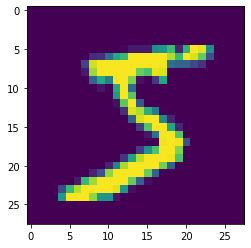

In [62]:
plt.imshow(train_X[0])

---

In [63]:
train_X = train_X.reshape(train_X.shape[0],-1)
test_X = test_X.reshape(test_X.shape[0],-1)

In [7]:
train_X.shape, test_X.shape

((60000, 784), (10000, 784))

In [8]:
np.unique(train_y, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949],
       dtype=int64))

In [9]:
np.unique(test_y, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009],
       dtype=int64))

Training

In [10]:
model = LogisticRegression(multi_class='ovr', random_state=42)

In [11]:
# ss = StandardScaler()
# train_X = ss.fit_transform(train_X)

In [12]:
model.fit(train_X, train_y)

LogisticRegression(multi_class='ovr', random_state=42)

In [13]:
# test_preds = model.predict(ss.transform(test_X))
test_preds = model.predict(test_X)

In [14]:
test_preds

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [15]:
accuracy_score(test_y, test_preds)

0.9179

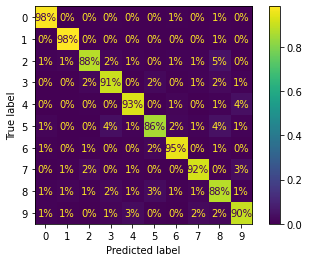

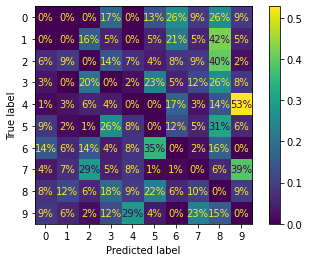

In [25]:
ConfusionMatrixDisplay.from_predictions(test_y, test_preds, normalize='true',
                                        values_format='.0%')
ConfusionMatrixDisplay.from_predictions(test_y, test_preds, normalize='true',
                                        values_format='.0%',
                                        sample_weight=(test_y!=test_preds))

Problem 1

In [10]:
model = KNeighborsClassifier()

In [11]:
model.fit(train_X, train_y)

KNeighborsClassifier()

In [12]:
test_preds = model.predict(test_X)

In [14]:
accuracy_score(test_y, test_preds)

0.9688

In [7]:
for n_neighbors in [2,4,8]:
    for weights in ['uniform', 'distance']:
        for p in [1,2]:
            model = KNeighborsClassifier(n_neighbors=n_neighbors,weights=weights,p=p, n_jobs=-1)
            model.fit(train_X, train_y)
            test_preds = model.predict(test_X)
            acc = accuracy_score(test_y, test_preds)
            print(f"{n_neighbors} | {weights} | {p} --> {round(100*acc,1)}%")

2 | uniform | 1 --> 95.4%
2 | uniform | 2 --> 96.3%
2 | distance | 1 --> 96.3%
2 | distance | 2 --> 96.9%
4 | uniform | 1 --> 96.1%
4 | uniform | 2 --> 96.8%
4 | distance | 1 --> 96.6%
4 | distance | 2 --> 97.1%
8 | uniform | 1 --> 95.9%
8 | uniform | 2 --> 96.7%
8 | distance | 1 --> 96.2%
8 | distance | 2 --> 97.1%


In [8]:
best_model = KNeighborsClassifier(n_neighbors=4,weights='distance',p=2, n_jobs=-1)

Data Augmentation

In [64]:
def shift_image(image, direction):
    image = image.copy()
    if direction=='right':
        image = image[:,:-1]
        image = np.concatenate((np.zeros((28,1)),image),axis=1)
    if direction=='left':
        image = image[:,1:]
        image = np.concatenate((image,np.zeros((28,1))),axis=1)
    if direction=='down':
        image = image[:-1,:]
        image = np.concatenate((np.zeros((1,28)),image),axis=0)
    if direction=='up':
        image = image[1:,:]
        image = np.concatenate((image,np.zeros((1,28))),axis=0)
    return image

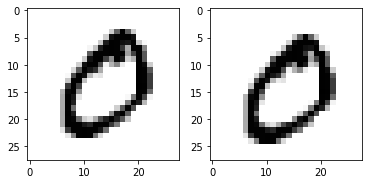

In [65]:
fig, ax = plt.subplots(1,2)
sample = train_X[1].reshape(28,28).copy()
ax[0].imshow(sample,cmap='binary')
ax[1].imshow(shift_image(sample,'down'),cmap='binary')

In [116]:
train_X_aug = []
for image in tqdm(train_X):
    for direction in ['up','down','left','right']:
        aug_data = shift_image(image.reshape(28,28), direction)
        aug_data = aug_data.reshape(-1,)
        train_X_aug.append(aug_data)

100%|██████████| 60000/60000 [00:02<00:00, 20791.04it/s]


In [117]:
len(train_X_aug), train_X_aug[0].shape

(240000, (784,))

In [118]:
train_X.shape

(60000, 784)

In [122]:
train_X_aug = np.asarray(train_X_aug)

In [123]:
train_X_aug.shape

(240000, 784)

In [127]:
train_X_new = np.vstack((train_X, train_X_aug))

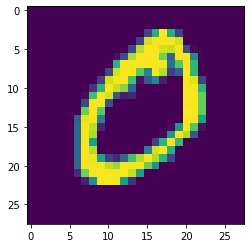

In [134]:
plt.imshow(train_X_new[60004].reshape(28,28))

In [138]:
train_y_aug = []
for y in train_y:
    for _ in range(4):
        train_y_aug.append(y)

In [143]:
train_y.shape

(60000,)

In [142]:
np.asarray(train_y_aug).shape

(240000,)

In [147]:
train_y_new = np.hstack((train_y, train_y_aug))

In [154]:
train_y_new[60004]

0

Training again

In [155]:
best_model = KNeighborsClassifier(n_neighbors=4,weights='distance',p=2, n_jobs=-1)

In [156]:
best_model.fit(train_X, train_y)
acc = accuracy_score(test_y, best_model.predict(test_X))
print(f'Acc : {100*acc}')

Acc : 97.14


In [157]:
best_model = KNeighborsClassifier(n_neighbors=4,weights='distance',p=2, n_jobs=-1)
best_model.fit(train_X_new, train_y_new)
acc = accuracy_score(test_y, best_model.predict(test_X))
print(f'Acc : {100*acc}')

Acc : 97.63


Spam Classifier

Building dataset

In [164]:
os.listdir('20030228_easy_ham/easy_ham/')[:2]

['00001.7c53336b37003a9286aba55d2945844c',
 '00002.9c4069e25e1ef370c078db7ee85ff9ac']

In [171]:
ham = []
spam = []
for d in os.listdir('.'):
    print(d)
    if 'spam' in d:
        for f in tqdm(os.listdir(os.path.join(d,d[9:]))):
            try:
                mail = open(os.path.join(d,d[9:],f),'r').read()
                spam.append(mail)
            except Exception as e:
                print(f'Error : {e}  | Failed --> {os.path.join(d,d[9:],f)}')
    elif 'ham' in d:
        for f in tqdm(os.listdir(os.path.join(d,d[9:]))):
            try:
                mail = open(os.path.join(d,d[9:],f),'r').read()
                ham.append(mail)
            except Exception as e:
                print(f'Error : {e}  | Failed --> {os.path.join(d,d[9:],f)}')
    else:
        pass

20030228_easy_ham


100%|██████████| 2501/2501 [00:00<00:00, 4985.82it/s]


20030228_hard_ham


100%|██████████| 251/251 [00:00<00:00, 3463.29it/s]


20030228_spam


...

Error : 'charmap' codec can't decode byte 0x81 in position 3124: character maps to <undefined>  | Failed --> 20030228_spam\spam\00116.29e39a0064e2714681726ac28ff3fdef
Error : 'charmap' codec can't decode byte 0x81 in position 2568: character maps to <undefined>  | Failed --> 20030228_spam\spam\00263.13fc73e09ae15e0023bdb13d0a010f2d
Error : 'charmap' codec can't decode byte 0x81 in position 2483: character maps to <undefined>  | Failed --> 20030228_spam\spam\00320.20dcbb5b047b8e2f212ee78267ee27ad
Error : 'charmap' codec can't decode byte 0x81 in position 2662: character maps to <undefined>  | Failed --> 20030228_spam\spam\00323.9e36bf05304c99f2133a4c03c49533a9
Error : 'charmap' codec can't decode byte 0x81 in position 2708: character maps to <undefined>  | Failed --> 20030228_spam\spam\00324.6f320a8c6b5f8e4bc47d475b3d4e86ef


100%|██████████| 501/501 [00:00<00:00, 4324.88it/s]


Error : 'charmap' codec can't decode byte 0x8f in position 1674: character maps to <undefined>  | Failed --> 20030228_spam\spam\00500.85b72f09f6778a085dc8b6821965a76f
20050311_spam_2


100%|██████████| 1397/1397 [00:00<00:00, 4185.07it/s]

Error : 'charmap' codec can't decode byte 0x8d in position 3062: character maps to <undefined>  | Failed --> 20050311_spam_2\spam_2\01065.9ecef01b01ca912fa35453196b4dae4c
Error : 'charmap' codec can't decode byte 0x90 in position 2832: character maps to <undefined>  | Failed --> 20050311_spam_2\spam_2\01227.04a4f94c7a73b29cb56bf38c7d526116
Error : 'charmap' codec can't decode byte 0x9d in position 4099: character maps to <undefined>  | Failed --> 20050311_spam_2\spam_2\01376.73e738e4cd8121ce3dfb42d190b193c9
exercise.ipynb


In [176]:
ham_df = pd.DataFrame({'email':ham, 'flag':0})
spam_df = pd.DataFrame({'email':spam, 'flag':1})

In [178]:
df = pd.concat([ham_df,spam_df],axis=0)

In [179]:
df['flag'].mean()

0.4070243482008188

In [180]:
df.shape

(4641, 2)

Baseline

In [199]:
cross_val_score(LogisticRegression(), df['email'].str.len().values.reshape(-1, 1), df['flag'].values, cv=3, n_jobs=-1, scoring='f1').mean()

0.19292604501607716

In [219]:
tfidf = TfidfVectorizer(max_features=10000)

In [220]:
train_X_tfidf = tfidf.fit_transform(df['email'])

In [221]:
cross_val_score(LogisticRegression(), train_X_tfidf, df['flag'].values, cv=3, n_jobs=-1, scoring='f1').mean()

0.8741631036182985